# Demo for Patch data
VR 2025-01-08

In [1]:
import retinanalysis as ra
import matplotlib.pyplot as plt
import numpy as np

# Single-cell browsing helpers: read-only DataJoint queries + notebook tables.
# Lives in retinanalysis/SCutils/explore.py, also reachable as ra.sc_explore.
from retinanalysis.SCutils import explore as sc

## Populate the database

Parse h5 to json, then place h5 and json in database dirs, then populate database.

`populate_database()` walks `H5_DIR` / `META_DIR`, and for anything already in
DataJoint it now compares the source files' modification times against the
`date_added` stored on the `Experiment` row. A meta `.json` or tags `.json` that
has been touched since ingest — a re-parsed h5, or a fresher copy synced down
from the shared drive — means the existing experiment gets dropped (cascading to
every downstream table) and re-ingested from the new json. Everything else is
skipped as before, so re-running the cell stays cheap.

Only the two json files are watched. Nothing in the database is read out of the
`.h5` itself, so re-copying a raw file bumps its mtime without changing anything
ingestible; pass `watch_data_file=True` if you want that to force a re-ingest
anyway, or `update_if_modified=False` for the old strictly append-only behaviour.

In [ ]:
# Ingest new dates, and refresh any date whose json changed since it was added.
# Returns {'n_ingested', 'added', 'updated', 'skipped'}.
summary = ra.populate_database()

print(f"\nnewly added : {len(summary['added'])}")
print(f"refreshed   : {len(summary['updated'])}")
print(f"errored     : {len(summary['skipped'])}")

### Which dates are out of date?

`ra.list_database_experiments()` is the read-only view behind that check: one row
per experiment with `date_added`, the newest watched source file and its mtime,
and an `is_stale` flag. Use it to see what the next populate would refresh
*before* running it, or to confirm afterwards that nothing is left behind.

In [ ]:
# Freshness of every row, resolved against the file paths stored at ingest time.
# is_stale == True means the json on disk is newer than date_added, i.e. the
# populate cell above would re-ingest it. After a successful populate this
# should come back empty.
df_db = ra.list_database_experiments()
print(f"{len(df_db)} experiments; {int(df_db['is_stale'].sum())} with newer source files.")
df_db.query('is_stale')[['exp_name', 'date_added', 'source_mtime', 'source_file']]

### Purging entries

Three verbs, in increasing order of damage. Every one of them cascades through
DataJoint, so deleting an `Experiment` also removes its animals, preparations,
cells, epoch groups, epoch blocks, epochs and responses.

| call | scope |
|---|---|
| `ra.purge_experiments(exp_name)` | one date, or a list of dates |
| `ra.reload_experiment_data(exp_name)` | drop one date, then re-ingest it from json |
| `ra.purge_database(confirm='YES_DELETE_ALL')` | every experiment; refuses to run without the sentinel |

`purge_experiments` is an alias for `ra.delete_experiments` — same function, and
both report which names were actually found. Nothing here touches the json or h5
files on disk, so anything you drop comes back on the next `populate_database()`.

**The calls below are commented out on purpose.** Uncomment the one you want.

In [ ]:
# Drop one date, or a list of them. Cascades to every downstream table, so the
# experiment's animals / cells / epoch blocks / epochs / responses go too.
# Safe to undo: re-run ra.populate_database() and the date comes back from json.
# ra.purge_experiments('2026-06-04_G')
# ra.purge_experiments(['2026-05-06_E', '2026-05-08_E'])

# Everything that is currently stale, dropped in one go. Re-running
# populate_database() above already does this for you — this is the manual
# version, for when you want the deletes to happen without the re-ingest.
# stale = ra.list_database_experiments().query('is_stale')['exp_name'].tolist()
# ra.purge_experiments(stale)

# Wipe the whole database. Refuses to run without the literal sentinel, since
# rebuilding all ~700 experiments from json takes a while.
# ra.purge_database(confirm='YES_DELETE_ALL')

print(f"{len(ra.list_database_experiments())} experiments currently in the database.")

In [6]:
ra.DJ_GUI.launch()           # starts Flask + Next.js, opens browser

Flask backend starting on http://127.0.0.1:5000
Globals populated
 * Serving Flask app 'dj_server.app'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


Next.js frontend starting on http://localhost:3000

DJ-GUI is running at http://localhost:3000
Press Ctrl+C to stop.



{'flask_thread': <Thread(Thread-6 (_run_flask), started daemon 123145632993280)>,
 'next_process': <Popen: returncode: None args: ['npm', 'run', 'next-dev']>}

127.0.0.1 - - [24/Jul/2026 16:50:44] "GET /init/list-databases HTTP/1.1" 200 -
127.0.0.1 - - [24/Jul/2026 16:50:44] "GET /init/list-databases HTTP/1.1" 200 -
127.0.0.1 - - [24/Jul/2026 16:50:57] "POST /init/start-database HTTP/1.1" 200 -


create database first!


127.0.0.1 - - [24/Jul/2026 16:51:05] "POST /init/create-database HTTP/1.1" 400 -


In [2]:
# Every single-cell (patch) experiment, i.e. is_mea=0.
# NOTE: experimenter / project / rig are not populated in the DB for patch data,
# so only exp_name, species and rig_type carry values.
df_sc_exps = sc.list_experiments()

529 single-cell experiments.


exp_name,species,rig_type
2017-11-21_B,Mouse,PATCH
2017-12-12_B,Mouse,PATCH
2018-06-22_B,Primate,PATCH
2018-09-06_B,Mouse,PATCH
2018-10-05_B,Primate,PATCH
2019-01-07_B,Mouse,PATCH
2019-01-08_B,Mouse,PATCH
2019-01-15_G,Primate,PATCH
2019-01-24_G,Primate,PATCH
2019-01-29_B,Mouse,PATCH


In [3]:
# Which dates ran a given protocol? Case-insensitive substring match.
# Shown one row per date (a loose search can hit thousands of blocks) with the
# block ids collapsed into ranges; click "all N blocks" for the per-block list.
# The returned frame is always one row per block.
df_blocks = sc.find_blocks('spotWithAnnularContrastReversingGrating')

35 blocks | 5 experiments | 1 protocol(s) matching 'spotWithAnnularContrastReversingGrating'


exp_name,blocks,protocols,block_ids
2026-04-23_E,17,spotWithAnnularContrastReversingGrating,"34281, 34284-34286, 34291, 34294-34295, 34305-34306, 34309, 34315, 34317, 34324-34325, 34330, 34333-34334"
2026-04-24_E,2,spotWithAnnularContrastReversingGrating,34360-34361
2026-04-28_E,7,spotWithAnnularContrastReversingGrating,"33036-33037, 33041-33042, 33044, 33090-33091"
2026-05-06_E,1,spotWithAnnularContrastReversingGrating,33130
2026-06-04_G,8,spotWithAnnularContrastReversingGrating,"35019-35022, 35031-35034"


exp_name,protocol,block_id
2026-04-23_E,spotWithAnnularContrastReversingGrating,34281
2026-04-23_E,spotWithAnnularContrastReversingGrating,34284
2026-04-23_E,spotWithAnnularContrastReversingGrating,34285
2026-04-23_E,spotWithAnnularContrastReversingGrating,34286
2026-04-23_E,spotWithAnnularContrastReversingGrating,34291
2026-04-23_E,spotWithAnnularContrastReversingGrating,34294
2026-04-23_E,spotWithAnnularContrastReversingGrating,34295
2026-04-23_E,spotWithAnnularContrastReversingGrating,34305
2026-04-23_E,spotWithAnnularContrastReversingGrating,34306
2026-04-23_E,spotWithAnnularContrastReversingGrating,34309


In [4]:
# One date as a tree: cell (type) -> recording technique -> protocol, with the
# block count, total minutes and block ids per protocol. df_exp is still the full
# per-block frame from get_exp_summary, so later cells can filter it.
exp_name = '2026-06-04_G'
df_exp = sc.summarize_experiment(exp_name)

2026-06-04_G | 4 cells | 64 blocks | 6 protocols | 140 min


cell,recording,protocol,blocks,minutes,block_ids
Cell1 (RGC\OFF-parasol),cell-attached,spotWithAnnularGrating,1,2.0,35023
Cell2 (RGC\OFF-parasol),cell-attached,ExpandingSpots,1,0.9,35024
,,SplitFieldCentering,1,0.1,35025
,,spotWithAnnularGrating,5,10.1,35026-35030
,,spotWithAnnularContrastReversingGrating,4,4.3,35031-35034
,,LinearEquivalentDiscConeLin,7,23.8,35035-35041
,whole-cell,spotWithAnnularGrating,3,6.1,35042-35044
,,LinearEquivalentDiscConeLin,4,18.9,35045-35048
Cell3 (RGC\OFF-parasol),cell-attached,spotWithAnnularGrating,5,10.2,35004-35008
,,ExpandingSpots,1,0.9,35009


## ExpandingSpots: raster, PSTH and area summation

Pick a cell and analyze its expanding-spots data. We require a **cell-attached** block on purpose — the analysis counts spikes, and whole-cell recordings have no extracellular spikes to detect. If the requested cell never ran the protocol, the analysis falls back to the first cell that did.

Three panels: the spike raster grouped by spot size, the Gaussian-kernel PSTH per spot size (port of `spikeTimeToPSTH.m`), and the area-summation curve fitted with a difference of Gaussians (`DoG.m` / `fitDoG.m`) to pull out the center and surround sigma.

In [5]:
cell_label = 'Cell1'
sc.protocol_tree(df_exp.query('cell_label == @cell_label'), height=300);

cell,recording,protocol,blocks,minutes,block_ids
Cell1 (RGC\OFF-parasol),cell-attached,spotWithAnnularGrating,1,2.0,35023


Cell1 has no cell-attached ExpandingSpots block; using Cell2.


Initializing StimBlock for 2026-06-04_G block 35024


  Could not resolve display params for 2026-06-04_G (ValueError: Unexpected Rig identified in MEA experiment name 2026-06-04_G !); continuing with empty display params (expected for single-cell / non-MEA rigs).
Initializing ResponseBlock for 2026-06-04_G block 35024
If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.
Loading frame monitor data from /Volumes/ChrisNewSSD/single_cell/chris_data/h5/2026-06-04_G.h5 ...
Loaded (27, 10500) frame_data.



Loading Amp1 data from /Volumes/ChrisNewSSD/single_cell/chris_data/h5/2026-06-04_G.h5 ...
Loaded (27, 10500) amp_data.

Max trial length in data points: 10000 = 1 s
Trial 1: Found 2557 peaks
Trial 1: Splitting data into 2 sections for KMeans clustering.


Trial 1: Found 1211 spikes
Rejected 1211/1211 spikes with amplitude < 40.00 peak amp.
Trial 1: no spikes!
Trial 2: Found 2535 peaks
Trial 2: Splitting data into 2 sections for KMeans clustering.
Trial 2: Found 589 spikes
Rejected 588/589 spikes with amplitude < 40.00 peak amp.
Trial 3: Found 2563 peaks
Trial 3: Splitting data into 2 sections for KMeans clustering.
Trial 3: Found 655 spikes
Rejected 651/655 spikes with amplitude < 40.00 peak amp.
Trial 4: Found 2506 peaks
Trial 4: Splitting data into 2 sections for KMeans clustering.
Trial 4: Found 9 spikes
Rejected 1/9 spikes with amplitude < 40.00 peak amp.
Trial 5: Found 2506 peaks


...

Trial 15: Splitting data into 2 sections for KMeans clustering.
Trial 15: Found 1242 spikes
Rejected 1242/1242 spikes with amplitude < 40.00 peak amp.
Trial 15: no spikes!
Trial 16: Found 2568 peaks
Trial 16: Splitting data into 2 sections for KMeans clustering.
Trial 16: Found 606 spikes
Rejected 605/606 spikes with amplitude < 40.00 peak amp.
Trial 17: Found 2550 peaks
Trial 17: Splitting data into 2 sections for KMeans clustering.
Trial 17: Found 585 spikes
Rejected 581/585 spikes with amplitude < 40.00 peak amp.
Trial 18: Found 2513 peaks


Trial 18: Splitting data into 2 sections for KMeans clustering.
Trial 18: Found 574 spikes
Rejected 566/574 spikes with amplitude < 40.00 peak amp.
Trial 19: Found 2500 peaks
Trial 19: Splitting data into 2 sections for KMeans clustering.
Trial 19: Found 617 spikes
Rejected 608/617 spikes with amplitude < 40.00 peak amp.
Trial 20: Found 2503 peaks
Trial 20: Splitting data into 2 sections for KMeans clustering.
Trial 20: Found 576 spikes
Rejected 565/576 spikes with amplitude < 40.00 peak amp.
Trial 21: Found 2489 peaks
Trial 21: Splitting data into 2 sections for KMeans clustering.
Trial 21: Found 12 spikes
Rejected 1/12 spikes with amplitude < 40.00 peak amp.
Trial 22: Found 2466 peaks


Trial 22: Splitting data into 2 sections for KMeans clustering.
Trial 22: Found 619 spikes
Rejected 605/619 spikes with amplitude < 40.00 peak amp.
Trial 23: Found 2488 peaks
Trial 23: Splitting data into 2 sections for KMeans clustering.
Trial 23: Found 623 spikes
Rejected 606/623 spikes with amplitude < 40.00 peak amp.
Trial 24: Found 2492 peaks
Trial 24: Splitting data into 2 sections for KMeans clustering.
Trial 24: Found 17 spikes
Rejected 0/17 spikes with amplitude < 40.00 peak amp.
Trial 25: Found 2472 peaks
Trial 25: Splitting data into 2 sections for KMeans clustering.


Trial 25: Found 19 spikes
Rejected 3/19 spikes with amplitude < 40.00 peak amp.
Trial 26: Found 2502 peaks
Trial 26: Splitting data into 2 sections for KMeans clustering.
Trial 26: Found 588 spikes
Rejected 577/588 spikes with amplitude < 40.00 peak amp.
Trial 27: Found 2490 peaks
Trial 27: Splitting data into 2 sections for KMeans clustering.
Trial 27: Found 535 spikes
Rejected 528/535 spikes with amplitude < 40.00 peak amp.
2026-06-04_G Cell2 (RGC\OFF-parasol) block 35024: 27 epochs, 14 spot sizes | sigma_c = 99.7 um, sigma_s = 146.2 um, Kc/Ks = 3.00/2.60, r2 = 0.980


{'Kc': 2.999999998986583,
 'sigma_c': 99.69942541970525,
 'Ks': 2.5955636221316496,
 'sigma_s': 146.18718658175956,
 'base': 4.022159333708058e-35,
 'r2': 0.980303203602433}

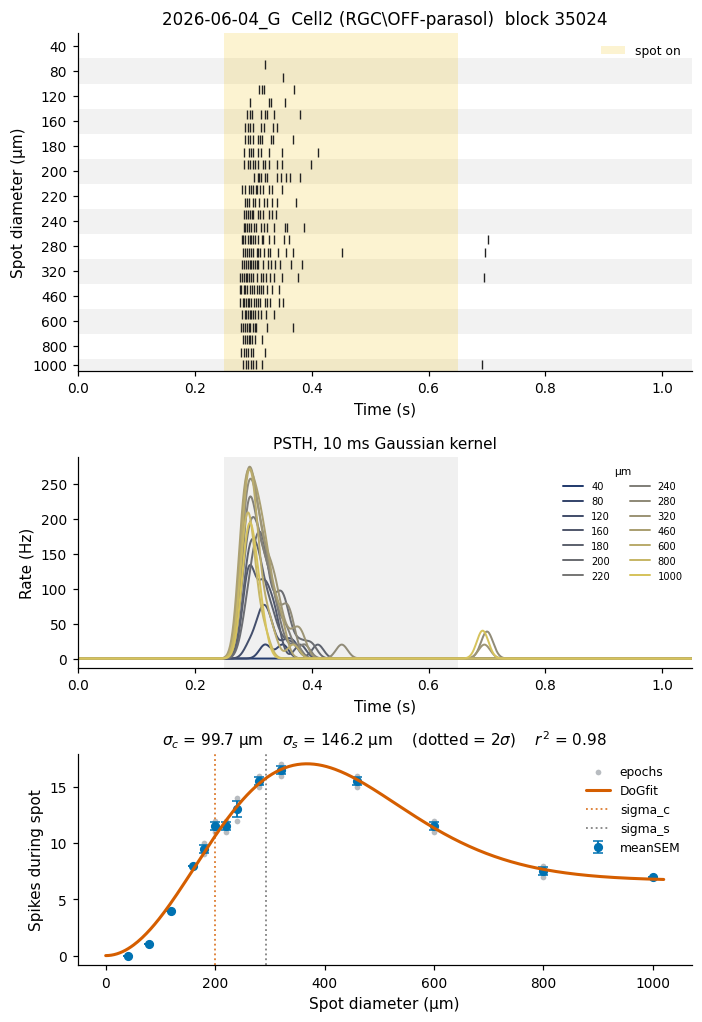

In [6]:
# ExpandingSpots for one cell, end to end: resolve a cell-attached block (block
# ids are DB auto-increments, so never hardcode one), load it, detect spikes,
# count them in the stimulus window, fit the difference-of-Gaussians area
# summation model, and plot the raster + summation curve.
# Port of analyzeExpandingSpots.m; the model matches DoG.m / fitDoG.m.
from retinanalysis.SCutils.protocols import expanding_spots as es

# min_peak_amplitude is the amplitude floor for spike detection -- the MATLAB's
# thresholdSpikeFactor. It matters: with no floor, this recording's clustering
# calls ~600 low-amplitude noise peaks per epoch "spikes" and then discards the
# whole epoch, leaving 20/27 epochs empty and r2 = 0.25. Anything from 20 to 80
# recovers the same sigmas here (r2 = 0.98). analyze_expanding_spots warns when
# too many epochs come back silent.
res = es.analyze_expanding_spots(exp_name, cell_label=cell_label,
                                 detector_kwargs={'min_peak_amplitude': 40})
res.fit

## Check the spike detection

Spike counts drive the whole area-summation fit, so eyeball a raw trace with the detected spikes marked. `i_epoch` indexes epochs in acquisition order.

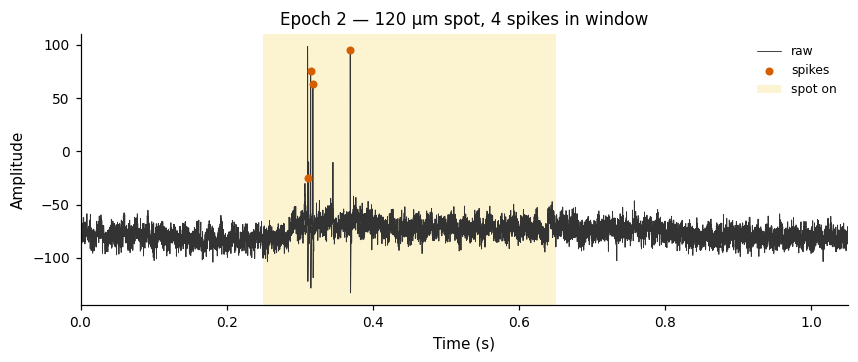

In [7]:
es.plot_example_trace(res, i_epoch=2);

## Export to Igor

`ra.igor_export` is the Python counterpart of `makeAxisStructChris.m`: it walks the matplotlib artists and writes the same flat HDF5 the Igor procedures (`DisplayFigFromMatlab`) already load — one group named after the file, `<wave>_Y` / `<wave>_X` pairs, colors, marker numbers, errorbar deltas.

Two habits make the export clean: give artists a `label=` (it becomes the Igor wave name, sanitized) and keep numbers out of those labels so wave names stay stable across cells. Shaded spans, text and legends are decoration and are not exported.

Set `RA_IGOR_DIR` to your Igor project folder to write straight where Igor reads; otherwise files land in `<OUTPUT_DIR>/igor_h5`.

In [8]:
# One .h5 per panel, as makeAxisStructChris.m writes one per axis. The group
# inside each file is named after the file stem, which Igor uses as the data
# folder name. res.fig is the figure drawn above, so nothing is redrawn here.
# Pass basedir=... to override RA_IGOR_DIR for a one-off.
paths = ra.igor_export.export_figure_to_h5(
    res.fig, f'expSpots_{exp_name}_{res.cell_label}'.replace('-', '_'))

wrote /private/tmp/claude-501/-Users-chrischen-Documents-GitHub-retinanalysis-src-retinanalysis/6845377a-0353-499e-8e0c-88096dd4879c/scratchpad/igor_out2/expSpots_2026_06_04_G_Cell21.h5  (1 waves: raster)
wrote /private/tmp/claude-501/-Users-chrischen-Documents-GitHub-retinanalysis-src-retinanalysis/6845377a-0353-499e-8e0c-88096dd4879c/scratchpad/igor_out2/expSpots_2026_06_04_G_Cell22.h5  (14 waves: n40, n80, n120, n160, n180, n200, n220, n240, n280, n320, n460, n600, n800, n1000)


wrote /private/tmp/claude-501/-Users-chrischen-Documents-GitHub-retinanalysis-src-retinanalysis/6845377a-0353-499e-8e0c-88096dd4879c/scratchpad/igor_out2/expSpots_2026_06_04_G_Cell23.h5  (5 waves: meanSEMerrY, epochs, DoGfit, sigma_c, sigma_s)
